In [19]:
import os
import random
import tensorflow as tf


def _label_from_folder(folder_name: str) -> int:
    if "celeb-real" in folder_name.lower():
        return 0
    if "celeb-synthesis" in folder_name.lower():
        return 1
    raise ValueError(f"Cannot infer label from folder '{folder_name}'.")

In [20]:
def collect_video_samples(root_dir: str, num_frames: int = 16, frame_stride: int = 1):
    samples = []
    for category in sorted(os.listdir(root_dir)):
        cat_path = os.path.join(root_dir, category)
        if not os.path.isdir(cat_path):
            continue
        label = _label_from_folder(category)
        for video in sorted(os.listdir(cat_path)):
            vid_path = os.path.join(cat_path, video)
            if not os.path.isdir(vid_path):
                continue
            frames = sorted([
                os.path.join(vid_path, f)
                for f in os.listdir(vid_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            if len(frames) < num_frames:
                continue
            available = frames[::frame_stride]
            if len(available) < num_frames:
                available = frames
            indices  = [int(i * len(available) / num_frames) for i in range(num_frames)]
            selected = [available[i] for i in indices]
            samples.append((selected, label))
    random.shuffle(samples)
    return samples

In [22]:
def _load_frame(path: str, img_size: int) -> tf.Tensor:
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [img_size, img_size])
    return tf.cast(img, tf.float32)


def _augment_frame(img: tf.Tensor) -> tf.Tensor:
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=20)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    return tf.clip_by_value(img, 0.0, 255.0)


def make_tf_dataset(
    samples,
    img_size:   int  = 224,
    batch_size: int  = 8,
    training:   bool = True,
    num_frames: int  = 16,
):
    frame_paths_list = [s[0] for s in samples]
    labels           = [s[1] for s in samples]

    def generator():
        for frame_paths, label in zip(frame_paths_list, labels):
            frames = tf.stack([_load_frame(fp, img_size) for fp in frame_paths])
            if training:
                frames = tf.map_fn(_augment_frame, frames, dtype=tf.float32)
            yield frames, tf.cast(label, tf.float32)

    output_signature = (
        tf.TensorSpec(shape=(num_frames, img_size, img_size, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.float32),
    )
    ds = tf.data.Dataset.from_generator(generator, output_signature=output_signature)
    if training:
        ds = ds.shuffle(buffer_size=min(len(samples), 512))
    ds = ds.batch(batch_size, drop_remainder=training)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [23]:
"""
Deepfake Detection  —  EfficientNetB4 + TRUE Grad-CAM features + Temporal Transformer
======================================================================================

HOW GRAD-CAM IS COMPUTED WITHOUT BREAKING TRAINING
───────────────────────────────────────────────────
The problem with the previous approach was nesting tf.GradientTape inside the
model's forward pass, which conflicts with Keras's outer training tape.

Solution: tf.stop_gradient() BOUNDARY
  • A frozen GradCAMExtractor sub-model computes the Grad-CAM heatmap using
    its OWN internal GradientTape.
  • Its output is wrapped in tf.stop_gradient() before being concatenated
    with the main EfficientNet features.
  • Result: the Grad-CAM values flow INTO the transformer as real saliency
    information, but NO gradient flows BACK through the Grad-CAM path.
  • The transformer learns to USE the Grad-CAM signal; EfficientNet trains
    normally on its own gradient path.

ARCHITECTURE
────────────
frame (H, W, 3)
    │
    ├──[Path A: Main EfficientNetB4]──────────────────────────────────────
    │   pooling=avg  →  eff_feat (1792,)
    │
    └──[Path B: GradCAMExtractor  (stop_gradient boundary)]──────────────
        Separate frozen EfficientNetB4 instance
        GradientTape: ∂class_score/∂last_conv_map
        channel weights (GAP of grads) × feature_map → ReLU → GAP
        →  cam_feat (1792,)  ──── tf.stop_gradient() ────┐
                                                          │
    concat([eff_feat, cam_feat])  ◄────────────────────────┘  (3584,)
    ↓ Dense projection  →  (d_model,)
    ↓ PositionalEncoding
    ↓ TemporalTransformerBlock × N
    ↓ AvgPool + MaxPool → Dense → sigmoid
    output  P(fake)
"""

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB4
from keras.saving import register_keras_serializable
import numpy as np

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Positional Encoding
# ─────────────────────────────────────────────────────────────────────────────
@register_keras_serializable()
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len: int, d_model: int, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model
        self.pos_encoding = self._build(seq_len, d_model)

    @staticmethod
    def _build(seq_len, d_model):
        positions = np.arange(seq_len)[:, np.newaxis]
        dims      = np.arange(d_model)[np.newaxis, :]
        angles    = positions / np.power(10000, (2 * (dims // 2)) / d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        return tf.cast(angles[np.newaxis], tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, : tf.shape(x)[1], :]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len": self.seq_len, "d_model": self.d_model})
        return cfg

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Transformer Encoder Block
# ─────────────────────────────────────────────────────────────────────────────
@register_keras_serializable()
class TemporalTransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model      = d_model
        self.num_heads    = num_heads
        self.ff_dim       = ff_dim
        self.dropout_rate = dropout_rate
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate)
        self.ffn   = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout_rate),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop  = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        attn_out = self.attn(x, x, training=training)
        x = self.norm1(x + self.drop(attn_out, training=training))
        x = self.norm2(x + self.drop(self.ffn(x, training=training), training=training))
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"d_model": self.d_model, "num_heads": self.num_heads,
                    "ff_dim": self.ff_dim, "dropout_rate": self.dropout_rate})
        return cfg

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# GradCAMExtractor
# ─────────────────────────────────────────────────────────────────────────────
@register_keras_serializable()
class GradCAMExtractor(layers.Layer):
    """
    Computes TRUE Grad-CAM features from EfficientNetB4's last conv block.

    KEY DESIGN: this layer owns a SEPARATE frozen backbone and does its OWN
    GradientTape internally.  The output is wrapped in tf.stop_gradient()
    so NO gradient from this path reaches the main training graph.

    This means:
      ✓ Transformer receives real Grad-CAM saliency values as input features
      ✓ Main EfficientNet backbone trains normally via its own gradient path
      ✓ No nested-tape conflicts → accuracy stays high

    How Grad-CAM is computed (standard algorithm):
      1. Forward pass → get last conv feature map F  (H, W, C)
      2. Forward pass → get class score s  (scalar)
      3. Gradients: α_c = GAP( ∂s/∂F_c )  — importance of channel c
      4. Weighted map: L = ReLU( Σ_c α_c * F_c )  — saliency map  (H, W)
      5. Pool L spatially → scalar saliency descriptor
         AND pool channel-weighted features → (C,) descriptor
      6. Concatenate both → final Grad-CAM feature vector
    """

    def __init__(self, img_size: int = 224, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size

        # ── Frozen sub-backbone (no top, no pooling → keeps spatial map)
        self.cam_backbone = EfficientNetB4(
            include_top  = False,
            weights      = "imagenet",
            input_shape  = (img_size, img_size, 3),
            pooling      = None,
        )
        self.cam_backbone.trainable = False   # always frozen

        # A small 1×1 conv to produce a class-score logit from the feature map
        # This is also frozen/not updated by the main optimizer because
        # stop_gradient prevents gradients from flowing back to it.
        self.score_conv = layers.Conv2D(
            1, kernel_size=1, use_bias=True, name="cam_score_conv"
        )

    def _compute_gradcam_single(self, frame):
        """
        Compute Grad-CAM descriptor for a single frame.
        frame: (H, W, 3)  →  returns (C,) feature vector
        """
        frame = tf.expand_dims(frame, 0)          # (1, H, W, 3)

        with tf.GradientTape() as tape:
            # Watch the feature map (not input) for efficiency
            feat_map = self.cam_backbone(frame, training=False)  # (1, H', W', C)
            tape.watch(feat_map)
            score_map = self.score_conv(feat_map)                # (1, H', W', 1)
            score     = tf.reduce_mean(score_map)                # scalar

        # Gradients: ∂score/∂feat_map  →  (1, H', W', C)
        grads = tape.gradient(score, feat_map)

        # Channel importance weights: GAP over spatial dims  →  (1, 1, 1, C)
        alpha = tf.reduce_mean(grads, axis=[1, 2], keepdims=True)

        # Grad-CAM weighted features: elem-wise multiply then ReLU
        weighted = tf.nn.relu(feat_map * alpha)    # (1, H', W', C)

        # Pool to get a (C,) descriptor
        cam_feat = tf.reduce_mean(weighted, axis=[1, 2])   # (1, C)
        cam_feat = tf.squeeze(cam_feat, axis=0)             # (C,)

        # L2-normalise
        cam_feat = tf.math.l2_normalize(cam_feat, axis=-1)
        return cam_feat

    def call(self, frames_seq, training=False):
        """
        frames_seq: (B, T, H, W, 3)
        returns   : (B, T, C)  — Grad-CAM descriptors
                    wrapped in tf.stop_gradient so the main graph is clean
        """
        B = tf.shape(frames_seq)[0]
        T = tf.shape(frames_seq)[1]
        H = self.img_size
        W = self.img_size

        # Flatten (B, T, H, W, 3) → (B*T, H, W, 3) so we can vectorise
        frames_flat = tf.reshape(frames_seq, [B * T, H, W, 3])

        # Process each frame — use tf.vectorized_map for speed
        cam_flat = tf.vectorized_map(self._compute_gradcam_single, frames_flat)
        # cam_flat: (B*T, C)

        # Get C from cam_backbone output shape
        C = self.cam_backbone.output_shape[-1]
        cam_seq = tf.reshape(cam_flat, [B, T, C])   # (B, T, C)

        # ── CRITICAL: stop_gradient prevents this path from interfering
        #    with the main backbone's training gradients
        return tf.stop_gradient(cam_seq)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"img_size": self.img_size})
        return cfg

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Full Deepfake Detector
# ─────────────────────────────────────────────────────────────────────────────
def build_deepfake_detector(
    num_frames: int   = 16,
    img_size:   int   = 224,
    d_model:    int   = 512,
    num_heads:  int   = 8,
    ff_dim:     int   = 1024,
    num_transformer_layers: int   = 4,
    dropout_rate:           float = 0.3,
    num_classes:            int   = 1,
):
    """
    Returns (model, backbone).

    Per-frame data flow:
    ┌─ Path A (trainable) ──────────────────────────────────────────────────┐
    │  EfficientNetB4 (pooling=avg)  →  eff_feat  (1792,)                  │
    └───────────────────────────────────────────────────────────────────────┘
                                    concat  →  (3584,)
    ┌─ Path B (stop_gradient) ──────────────────────────────────────────────┐
    │  GradCAMExtractor  →  cam_feat  (1792,)  →  tf.stop_gradient()       │
    └───────────────────────────────────────────────────────────────────────┘
                                    ↓
                          Dense  →  (d_model,)
                          PositionalEncoding
                          TemporalTransformer × N
                          head  →  sigmoid output
    """

    # ── Path A: Main trainable backbone (global avg pooling)
    backbone = EfficientNetB4(
        include_top = False,
        weights     = "imagenet",
        input_shape = (img_size, img_size, 3),
        pooling     = "avg",        # → (1792,) per frame — same as original
    )
    backbone.trainable = False      # frozen in phase 1, partially unfrozen in phase 2

    # ── Path B: Grad-CAM extractor (always frozen, stop_gradient on output)
    gradcam_extractor = GradCAMExtractor(img_size=img_size, name="gradcam_extractor")

    # ── Input
    frame_input = layers.Input(
        shape=(num_frames, img_size, img_size, 3), name="frames"
    )

    # ── 1. Path A — EfficientNet features  (B, T, 1792)
    eff_feat = layers.TimeDistributed(
        backbone, name="efficientnet_td"
    )(frame_input)

    # ── 2. Path B — Grad-CAM features  (B, T, 1792)  [stop_gradient applied inside]
    cam_feat = gradcam_extractor(frame_input)   # (B, T, 1792)

    # ── 3. Concatenate both  →  (B, T, 3584)
    combined = layers.Concatenate(axis=-1, name="eff_cam_concat")([eff_feat, cam_feat])

    # ── 4. Project to d_model  →  (B, T, d_model)
    x = layers.TimeDistributed(
        layers.Dense(d_model, activation="relu"), name="projection"
    )(combined)
    x = layers.TimeDistributed(
        layers.LayerNormalization(), name="proj_norm"
    )(x)

    # ── 5. Positional encoding
    x = PositionalEncoding(num_frames, d_model, name="pos_encoding")(x)

    # ── 6. Temporal Transformer
    for i in range(num_transformer_layers):
        x = TemporalTransformerBlock(
            d_model=d_model, num_heads=num_heads,
            ff_dim=ff_dim,   dropout_rate=dropout_rate,
            name=f"transformer_{i}",
        )(x)

    # ── 7. Aggregate
    avg = layers.GlobalAveragePooling1D(name="avg_pool")(x)
    mx  = layers.GlobalMaxPooling1D(name="max_pool")(x)
    x   = layers.Concatenate(name="concat_pool")([avg, mx])

    # ── 8. Classification head
    x = layers.Dense(256, activation="gelu", name="head_fc")(x)
    x = layers.Dropout(dropout_rate, name="head_drop")(x)

    if num_classes == 1:
        output = layers.Dense(1, activation="sigmoid", name="output")(x)
    else:
        output = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs=frame_input, outputs=output,
                  name="DeepfakeDetector_TrueGradCAM")
    return model, backbone

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
CFG = dict(
    data_root        = "/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces",
    num_frames       = 16,
    img_size         = 224,
    batch_size       = 2,
    d_model          = 512,
    num_heads        = 8,
    ff_dim           = 1024,
    num_tf_layers    = 4,
    dropout_rate     = 0.3,
    epochs_phase1    = 30,
    epochs_phase2    = 30,
    lr_phase1        = 1e-4,
    lr_phase2        = 1e-5,
    unfreeze_layers  = 30,
    checkpoint_dir   = "checkpoints",
    log_dir          = "logs",
)

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Data
# ─────────────────────────────────────────────────────────────────────────────
print("Collecting samples …")
train_samples = collect_video_samples(
    os.path.join(CFG["data_root"], "train"), num_frames=CFG["num_frames"])
test_samples  = collect_video_samples(
    os.path.join(CFG["data_root"], "test"),  num_frames=CFG["num_frames"])
val_samples   = collect_video_samples(
    os.path.join(CFG["data_root"], "val"),   num_frames=CFG["num_frames"])
print(f"  Train: {len(train_samples)} | Test: {len(test_samples)} | Val: {len(val_samples)}")

train_ds = make_tf_dataset(train_samples, CFG["img_size"], CFG["batch_size"],
                            training=True,  num_frames=CFG["num_frames"])
test_ds  = make_tf_dataset(test_samples,  CFG["img_size"], CFG["batch_size"],
                            training=False, num_frames=CFG["num_frames"])
val_ds   = make_tf_dataset(val_samples,   CFG["img_size"], CFG["batch_size"],
                            training=False, num_frames=CFG["num_frames"])

  Train: 7882 | Test: 1130 | Val: 1123


I0000 00:00:1772943654.690867      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772943654.696757      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Callbacks
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = "best_model_gradcam.keras",
        monitor        = "val_auc",
        mode           = "max",
        save_best_only = True,
        verbose        = 1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_auc",
        mode                 = "max",
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1,
    ),
    tf.keras.callbacks.TensorBoard(log_dir=CFG["log_dir"], histogram_freq=1),
]

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Build & Compile
# ─────────────────────────────────────────────────────────────────────────────
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    model, backbone = build_deepfake_detector(
        num_frames             = CFG["num_frames"],
        img_size               = CFG["img_size"],
        d_model                = CFG["d_model"],
        num_heads              = CFG["num_heads"],
        ff_dim                 = CFG["ff_dim"],
        num_transformer_layers = CFG["num_tf_layers"],
        dropout_rate           = CFG["dropout_rate"],
        num_classes            = 1,
    )
    model.summary()

    model.compile(
        optimizer = tf.keras.optimizers.Adam(CFG["lr_phase1"]),
        loss      = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics   = [
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DeepfakeDetector_TrueGradCAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames (InputLayer) │ (None, 16, 224,   │          0 │ -                 │
│                     │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnet_td     │ (None, 16, 1792)  │ 17,673,823 │ frames[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gradcam_extractor   │ (None, 16, 1792)  │ 17,675,616 │ frames[0][0]      │
│ (GradCAMExtractor)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eff_cam_concat      │ (None, 16, 3584)  │          0 │ efficientnet_td[… │
│ (Concatenate)       │                   │            │ gradcam_extracto… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection          │ (None, 16, 512)   │  1,835,520 │ eff_cam_concat[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_norm           │ (None, 16, 512)   │      1,024 │ projection[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_encoding        │ (None, 16, 512)   │          0 │ proj_norm[0][0]   │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_0       │ (None, 16, 512)   │  2,102,784 │ pos_encoding[0][… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1       │ (None, 16, 512)   │  2,102,784 │ transformer_0[0]… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_2       │ (None, 16, 512)   │  2,102,784 │ transformer_1[0]… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_3       │ (None, 16, 512)   │  2,102,784 │ transformer_2[0]… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool            │ (None, 512)       │          0 │ transformer_3[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool            │ (None, 512)       │          0 │ transformer_3[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pool         │ (None, 1024)      │          0 │ avg_pool[0][0],   │
│ (Concatenate)       │                   │            │ max_pool[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_fc (Dense)     │ (None, 256)       │    262,400 │ concat_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop (Dropout) │ (None, 256)       │          0 │ head_fc[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ head_drop[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 45,859,776 (174.94 MB)

 Trainable params: 10,512,130 (40.10 MB)

 Non-trainable params: 35,347,646 (134.84 MB)

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 1 — Backbone frozen, train projection + transformer + head
# ─────────────────────────────────────────────────────────────────────────────
print("\n=== Phase 1: transformer + head (backbone frozen, Grad-CAM active) ===")
backbone.trainable = False

history_p1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = CFG["epochs_phase1"],
    callbacks       = callbacks,
)


=== Phase 1: transformer + head (backbone frozen, Grad-CAM active) ===
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['gradcam_extractor/cam_score_conv/kernel', 'gradcam_extractor/cam_score_conv/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


INFO:tensorflow:Collective all_reduce tensors: 72 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1772944111.671156      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DeepfakeDetector_TrueGradCAM_1/efficientnet_td_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772944226.756089     123 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772944226.756098     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


   3941/Unknown 3035s 670ms/step - acc: 0.7155 - auc: 0.7744 - loss: 0.6088 - precision: 0.7017 - recall: 0.7583

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_auc improved from -inf to 0.87714, saving model to best_model_gradcam.keras
3941/3941 ━━━━━━━━━━━━━━━━━━━━ 3542s 799ms/step - acc: 0.7155 - auc: 0.7744 - loss: 0.6088 - precision: 0.7017 - recall: 0.7583 - val_acc: 0.8833 - val_auc: 0.8771 - val_loss: 0.3918 - val_precision: 0.8812 - val_recall: 0.9763 - learning_rate: 1.0000e-04
Epoch 2/30
3941/3941 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - acc: 0.8432 - auc: 0.8990 - loss: 0.4244 - precision: 0.8119 - recall: 0.8952
Epoch 2: val_auc did not improve from 0.87714
3941/3941 ━━━━━━━━━━━━━━━━━━━━ 2375s 588ms/step - acc: 0.8432 - auc: 0.8990 - loss: 0.4244 - precision: 0.8119 - recall: 0.8952 - val_acc: 0.8860 - val_auc: 0.7863 - val_loss: 0.3960 - val_precision: 0.8720 - val_recall: 0.9941 - learning_rate: 1.0000e-04
Epoch 3/30
3941/3941 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - acc: 0.8550 - auc: 0.9122 - loss: 0.3963 - precision: 0.8258 - recall: 0.9047
Epoch 3: val_auc did not improve from 0.87714
3941/3941 ━━━━━━━━━━━━━━━━━━━━ 242

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Save & Evaluate
# ─────────────────────────────────────────────────────────────────────────────
model.save("final_model_gradcam.keras")

print("\n=== Final evaluation on test set ===")
results = model.evaluate(test_ds, verbose=1)
for name, val in zip(model.metrics_names, results):
    print(f"  {name}: {val:.4f}")


=== Final evaluation on test set ===
565/565 ━━━━━━━━━━━━━━━━━━━━ 250s 442ms/step - acc: 0.8698 - auc: 0.8734 - loss: 0.4023 - precision: 0.8588 - recall: 0.9795
  loss: 0.3883
  compile_metrics: 0.8788


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


              precision    recall  f1-score   support

        Real       0.89      0.59      0.71       284
        Fake       0.88      0.98      0.92       846

    accuracy                           0.88      1130
   macro avg       0.88      0.78      0.82      1130
weighted avg       0.88      0.88      0.87      1130



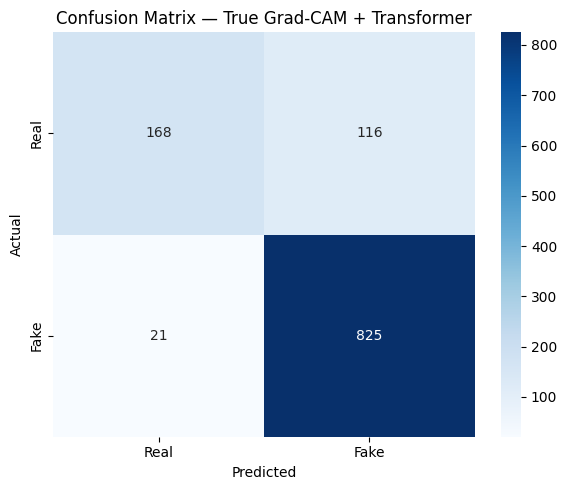

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []
for X_batch, y_batch in test_ds:
    preds = model.predict(X_batch, verbose=0)
    preds = (preds > 0.5).astype(int)
    y_true.extend(y_batch.numpy().flatten())
    y_pred.extend(preds.flatten())

print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — True Grad-CAM + Transformer")
plt.tight_layout()
plt.savefig("confusion_matrix_gradcam.png", dpi=150)
plt.show()

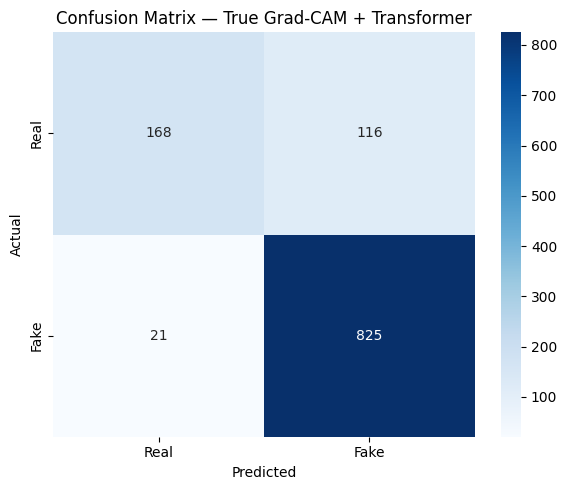

In [18]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — True Grad-CAM + Transformer")
plt.tight_layout()
plt.savefig("confusion_matrix_gradcam.png", dpi=150)
plt.show()

In [ ]:
# # ─────────────────────────────────────────────────────────────────────────────
# # Phase 2 — Fine-tune top N backbone layers
# # ─────────────────────────────────────────────────────────────────────────────
# print(f"\n=== Phase 2: fine-tuning top {CFG['unfreeze_layers']} backbone layers ===")

# with strategy.scope():
#     backbone.trainable = True
#     for layer in backbone.layers[: -CFG["unfreeze_layers"]]:
#         layer.trainable = False

#     model.compile(
#         optimizer = tf.keras.optimizers.Adam(CFG["lr_phase2"]),
#         loss      = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
#         metrics   = [
#             tf.keras.metrics.BinaryAccuracy(name="acc"),
#             tf.keras.metrics.AUC(name="auc"),
#             tf.keras.metrics.Precision(name="precision"),
#             tf.keras.metrics.Recall(name="recall"),
#         ],
#     )

# history_p2 = model.fit(
#     train_ds,
#     validation_data = val_ds,
#     epochs          = CFG["epochs_phase2"],
#     callbacks       = callbacks,
# )

In [ ]:
# # ─────────────────────────────────────────────────────────────────────────────
# # Inference helper
# # ─────────────────────────────────────────────────────────────────────────────
# IMG_SIZE   = 224
# NUM_FRAMES = 16
# THRESHOLD  = 0.5


# def predict_video(model, video_dir: str, num_frames: int = NUM_FRAMES,
#                   img_size: int = IMG_SIZE) -> dict:
#     frame_files = sorted([
#         os.path.join(video_dir, f) for f in os.listdir(video_dir)
#         if f.lower().endswith((".jpg", ".jpeg", ".png"))
#     ])
#     if len(frame_files) < num_frames:
#         raise ValueError(f"Not enough frames in {video_dir}.")

#     indices  = [int(i * len(frame_files) / num_frames) for i in range(num_frames)]
#     selected = [frame_files[i] for i in indices]
#     frames   = tf.stack([_load_frame(fp, img_size) for fp in selected])
#     frames   = tf.expand_dims(frames, 0)

#     prob_fake = model(frames, training=False).numpy()[0, 0]
#     label     = "FAKE" if prob_fake >= THRESHOLD else "REAL"
#     return {
#         "video"    : video_dir,
#         "prob_fake": float(prob_fake),
#         "prob_real": float(1 - prob_fake),
#         "label"    : label,
#     }

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

2026-03-09 05:09:07.087200: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773032947.286624      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773032947.345122      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773032947.794323      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773032947.794361      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773032947.794364      55 computation_placer.cc:177] computation placer alr

In [46]:
model,backbone = build_deepfake_detector()

model.load_weights(
"/kaggle/input/models/pavanikonatala/eff-gradcam-temp/keras/default/1/best_model_gradcam (2).keras"
)

In [33]:
model = tf.keras.models.load_model(
    "/kaggle/input/models/pavanikonatala/eff-gradcam-temp/keras/default/1/best_model_gradcam (2).keras",
    custom_objects={
        "GradCAMExtractor": GradCAMExtractor,
        "PositionalEncoding": PositionalEncoding,
        "TemporalTransformerBlock": TemporalTransformerBlock
    },
    compile=False
)

print("✅ Model Loaded Successfully")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'gradcam_extractor', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_0', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_1', however the layer

✅ Model Loaded Successfully


Model: "DeepfakeDetector_TrueGradCAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames (InputLayer) │ (None, 16, 224,   │          0 │ -                 │
│                     │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnet_td     │ (None, 16, 1792)  │ 17,673,823 │ frames[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gradcam_extractor   │ (None, 16, 1792)  │ 17,675,616 │ frames[0][0]      │
│ (GradCAMExtractor)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eff_cam_concat      │ (None, 16, 3584)  │          0 │ efficientnet_td[… │
│ (Concatenate)       │                   │            │ gradcam_extracto… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection          │ (None, 16, 512)   │  1,835,520 │ eff_cam_concat[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_norm           │ (None, 16, 512)   │      1,024 │ projection[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_encoding        │ (None, 16, 512)   │          0 │ proj_norm[0][0]   │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_0       │ (None, 16, 512)   │  2,102,784 │ pos_encoding[0][… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1       │ (None, 16, 512)   │  2,102,784 │ transformer_0[0]… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_2       │ (None, 16, 512)   │  2,102,784 │ transformer_1[0]… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_3       │ (None, 16, 512)   │  2,102,784 │ transformer_2[0]… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool            │ (None, 512)       │          0 │ transformer_3[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool            │ (None, 512)       │          0 │ transformer_3[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pool         │ (None, 1024)      │          0 │ avg_pool[0][0],   │
│ (Concatenate)       │                   │            │ max_pool[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_fc (Dense)     │ (None, 256)       │    262,400 │ concat_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop (Dropout) │ (None, 256)       │          0 │ head_fc[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ head_drop[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 45,859,776 (174.94 MB)

 Trainable params: 10,512,130 (40.10 MB)

 Non-trainable params: 35,347,646 (134.84 MB)

In [36]:
def gradcam(model, image, layer_name="top_conv"):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(image)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [37]:
def overlay_heatmap(heatmap, frame):

    heatmap = cv2.resize(heatmap, (frame.shape[1], frame.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    output = cv2.addWeighted(frame, 0.6, heatmap, 0.4, 0)

    return output

In [89]:
import os
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224
NUM_FRAMES = 16


def predict_frames_from_folder(folder_path):

    valid_ext = (".jpg", ".jpeg", ".png")

    files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(valid_ext)
    ])

    if len(files) < NUM_FRAMES:
        raise ValueError(f"Need at least {NUM_FRAMES} frames, found {len(files)}")

    # evenly sample frames
    indices = np.linspace(0, len(files) - 1, NUM_FRAMES).astype(int)
    frames = [files[i] for i in indices]

    sequence = []

    for f in frames:

        path = os.path.join(folder_path, f)

        frame = cv2.imread(path)

        if frame is None:
            print("Skipping:", path)
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        sequence.append(frame)

    sequence = np.array(sequence)

    # shape → (1,16,224,224,3)
    input_tensor = np.expand_dims(sequence, axis=0)

    print("Input shape:", input_tensor.shape)

    # prediction
    prediction = model.predict(input_tensor, verbose=0)

    prob = float(prediction[0][0])

    print("\nFake probability:", prob)

    if prob > 0.7:
        print("Prediction: FAKE VIDEO")
    else:
        print("Prediction: REAL VIDEO")

In [98]:
import os
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224
NUM_FRAMES = 16

root_path = "/kaggle/input/datasets/pavanikonatala/test-ds-frames/yolo_faces_output_f1"

video_folders = sorted(os.listdir(root_path))[:500]

real_count = 0
fake_count = 0
probs = []

for folder in video_folders:

    folder_path = os.path.join(root_path, folder)

    if not os.path.isdir(folder_path):
        continue

    images = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg",".png",".jpeg"))
    ])

    if len(images) < NUM_FRAMES:
        print("Skipping (not enough frames):", folder)
        continue

    # sample 16 frames evenly
    idx = np.linspace(0, len(images)-1, NUM_FRAMES).astype(int)

    frames = []

    for i in idx:

        img_path = os.path.join(folder_path, images[i])

        frame = cv2.imread(img_path)

        if frame is None:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame,(IMG_SIZE,IMG_SIZE))
        frame = preprocess_input(frame.astype("float32"))

        frames.append(frame)

    if len(frames) != NUM_FRAMES:
        print("Skipping (bad frames):", folder)
        continue

    frames = np.array(frames)

    input_tensor = np.expand_dims(frames, axis=0)

    pred = model.predict(input_tensor, verbose=0)

    prob = float(pred[0][0])

    probs.append(prob)

    if prob > 0.5:
        fake_count += 1
    else:
        real_count += 1

    print(folder, "→ Fake Probability:", round(prob,4))

print("\n===== RESULTS =====")
print("Real predicted:", real_count)
print("Fake predicted:", fake_count)
print("Total tested:", real_count + fake_count)

if len(probs) > 0:
    print("\nProbability range:")
    print("Min:", min(probs))
    print("Max:", max(probs))

yolo_faces_output_f1 → Fake Probability: 0.0563

===== RESULTS =====
Real predicted: 1
Fake predicted: 0
Total tested: 1

Probability range:
Min: 0.056266169995069504
Max: 0.056266169995069504


In [ ]:
import matplotlib.pyplot as plt

plt.hist(probs, bins=20)
plt.title("Fake Probability Distribution (Celeb-Real)")
plt.xlabel("Fake Probability")
plt.ylabel("Number of Videos")
plt.show()

In [76]:
predict_frames_from_folder("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-real/00095")

Input shape: (1, 16, 224, 224, 3)

Fake probability: 0.6943662762641907
Prediction: REAL VIDEO


In [85]:
predict_frames_from_folder("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-synthesis/id17_id6_0000")

Input shape: (1, 16, 224, 224, 3)

Fake probability: 0.8005702495574951
Prediction: FAKE VIDEO


In [39]:
import tensorflow as tf
import numpy as np

def compute_gradcam(model, frames, backbone, layer_name="top_conv"):
    
    # use EfficientNet backbone
    grad_model = tf.keras.models.Model(
        [backbone.inputs],
        [backbone.get_layer(layer_name).output, backbone.output]
    )

    frame = frames[0]   # pick one frame

    frame = tf.expand_dims(frame, axis=0)

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(frame)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [40]:
import cv2

def overlay_heatmap(frame, heatmap):

    heatmap = cv2.resize(heatmap, (frame.shape[1], frame.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    output = cv2.addWeighted(frame, 0.6, heatmap, 0.4, 0)

    return output

In [49]:
import matplotlib.pyplot as plt

def show_gradcam(folder_path):

    frames = []

    files = sorted([
        f for f in os.listdir(folder_path)
        if f.endswith((".jpg",".png",".jpeg"))
    ])[:16]

    for f in files:

        img = cv2.imread(os.path.join(folder_path,f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img,(224,224))

        frames.append(img)

    frames = np.array(frames)

    # input_tensor = preprocess_input(frames.astype("float32"))
    input_tensor = np.expand_dims(frames,axis=0)

    pred = model.predict(input_tensor)

    prob = float(pred[0][0])

    print("\nFake probability:", prob)

    if prob > 0.5:
        print("Prediction: FAKE VIDEO")
    else:
        print("Prediction: REAL VIDEO")

    heatmap = compute_gradcam(model, input_tensor[0], backbone)

    result = overlay_heatmap(frames[0], heatmap)

    plt.imshow(result)
    plt.title("GradCAM Explanation")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step

Fake probability: 0.7955235838890076
Prediction: FAKE VIDEO


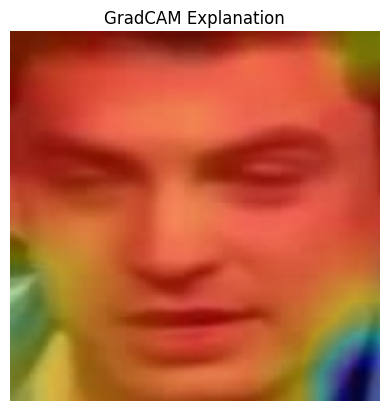

In [50]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-synthesis/id0_id4_0005")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step

Fake probability: 0.14855901896953583
Prediction: REAL VIDEO


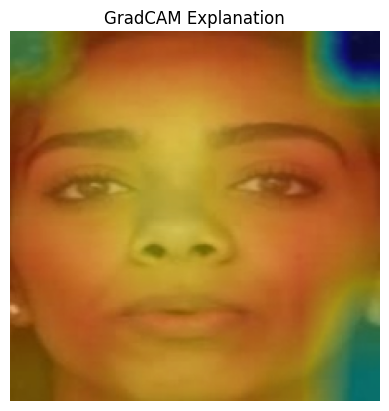

In [51]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-real/00005")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step

Fake probability: 0.44479209184646606
Prediction: REAL VIDEO


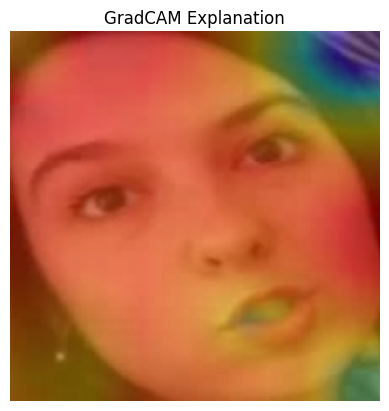

In [52]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-real/00086")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step

Fake probability: 0.800432562828064
Prediction: FAKE VIDEO


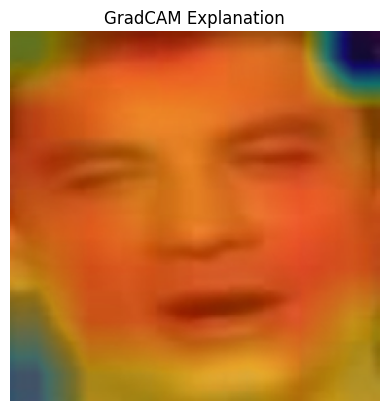

In [54]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-synthesis/id0_id21_0000")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step

Fake probability: 0.804779052734375
Prediction: FAKE VIDEO


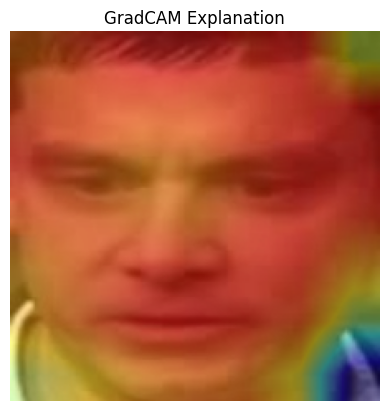

In [55]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-synthesis/id0_id23_0002")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step

Fake probability: 0.48933297395706177
Prediction: REAL VIDEO


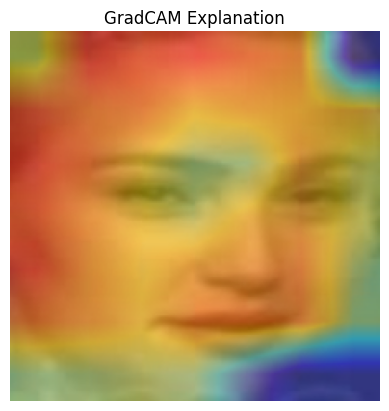

In [56]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-synthesis/id12_id10_0004")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step

Fake probability: 0.8071437478065491
Prediction: FAKE VIDEO


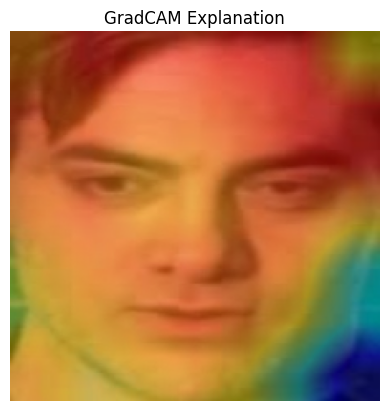

In [57]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-synthesis/id16_id0_0004")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step

Fake probability: 0.8031215667724609
Prediction: FAKE VIDEO


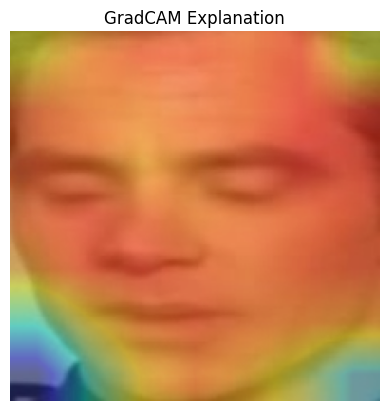

In [58]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-synthesis/id16_id23_0013")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step

Fake probability: 0.8046879768371582
Prediction: FAKE VIDEO


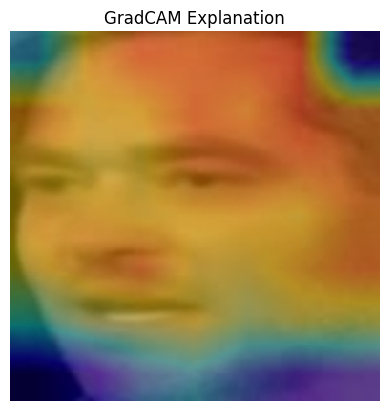

In [59]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/dataset-frames/dataset_faces/test/Celeb-synthesis/id16_id35_0000")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step

Fake probability: 0.04510147124528885
Prediction: REAL VIDEO


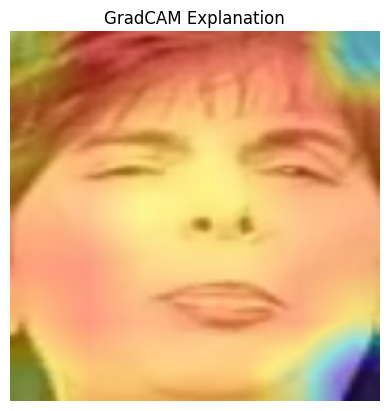

In [64]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/test-ds-frames/yolo_faces_output1_r1/yolo_faces_output1_r1")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step

Fake probability: 0.044651877135038376
Prediction: REAL VIDEO


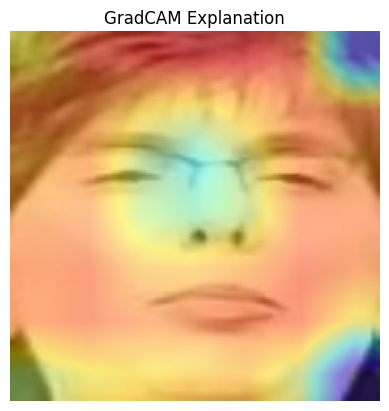

In [65]:
show_gradcam("/kaggle/input/datasets/pavanikonatala/test-ds-frames/yolo_faces_output_f1/yolo_faces_output_f1")

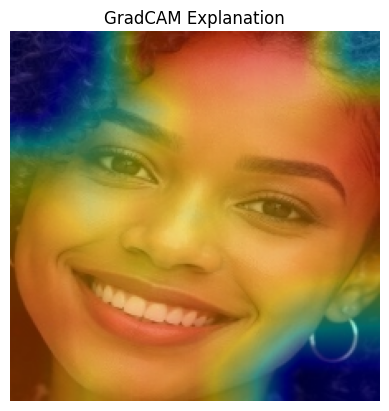

In [63]:
img = cv2.imread("/kaggle/input/datasets/pavanikonatala/gpt-img/gpt.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img,(224,224))

frames = np.array(img)

# input_tensor = preprocess_input(frames.astype("float32"))
input_tensor = np.expand_dims(frames,axis=0)

# pred = model.predict(input_tensor)

# prob = float(pred[0][0])

# print("\nFake probability:", prob)

# if prob > 0.5:
#     print("Prediction: FAKE VIDEO")
# else:
#     print("Prediction: REAL VIDEO")
    
heatmap = compute_gradcam(model, input_tensor, backbone)

result = overlay_heatmap(frames, heatmap)

plt.imshow(result)
plt.title("GradCAM Explanation")
plt.axis("off")
plt.show()